In [2]:
# STEP 1 — IMPORT LIBRARIES
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# display settings
pd.set_option('display.max_columns', None)

In [4]:
# STEP 2 — LOAD DATASET
df = pd.read_csv("productivity_dataset.csv")
# first 5 rows
df.head()

,Timestamp,Username,E-mail,Gender,Age,Occupation,How many hours do you use your phone on a typical day?,How long before sleeping do you stop using your phone?,How soon after waking up do you check your phone?,How many hours do you sleep on a typical night ?,How would you rate the quality of your sleep?,How consistent is your sleep schedule?,How many hours do you spend on work or study on a typical day ?,How well can you focus on a task without reaching for your phone?,How often does your phone interrupt you during work or study?,How would you rate your stress level on a typical day?,How productive are you on a typical day?
0,2026/04/27 12:53:47 PM GMT+5:30,vasanthappu08@gmail.com,vasanth2572@gmail.com,Male,21 - 30,Working professional,2 hours,I use it right until I fall asleep,Within 5 minutes of waking up,7 hours,2.0,Mostly consistent — varies by about 30–60 minutes,8 hours,Low — I find it very hard to focus without my ...,Sometimes — I check it roughly every hour,5.0,🟡 Medium — I complete some tasks but get distr...
1,2026/04/27 12:59:22 PM GMT+5:30,2024tm93663@wilp.bits-pilani.ac.in,anburajmca@gmail.com,Male,31 - 45,Working professional,3,I stop 30–60 minutes before sleeping,Within 5 minutes of waking up,2,3.0,Mostly consistent — varies by about 30–60 minutes,3,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,3.0,🟡 Medium — I complete some tasks but get distr...
2,2026/04/27 1:54:30 PM GMT+5:30,rusha.rama107@gmail.com,rusha.rama107@gmail.com,Female,45 +,Working professional,Two,I stop 30–60 minutes before sleeping,Within 5 minutes of waking up,6,4.0,Mostly consistent — varies by about 30–60 minutes,8 hours 30 minutes,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,4.0,🟢 High — I complete most of my planned tasks a...
3,2026/04/27 2:27:08 PM GMT+5:30,shivadasmenon59@gmail.com,shivadasmenon59@gmail.com,Male,45 +,Others,1 hour,I stop 30–60 minutes before sleeping,After 1 hour or more,6 hours,4.0,Very consistent — same time every day,0,High — I can focus for long stretches without ...,Rarely — only during planned breaks,2.0,🟢 High — I complete most of my planned tasks a...
4,2026/04/27 2:27:48 PM GMT+5:30,nandhun92@gmail.com,nandhun92@gmail.com,Male,31 - 45,Working professional,4,I use it right until I fall asleep,I don't check my phone first thing,7,3.0,Inconsistent — varies by 1–2 hours,10,High — I can focus for long stretches without ...,Rarely — only during planned breaks,3.0,🟡 Medium — I complete some tasks but get distr...


In [5]:
# STEP 3 — BASIC DATASET INSPECTION

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(200, 17)

Column Names:
Index(['Timestamp', 'Username', 'E-mail', 'Gender', 'Age', 'Occupation',
       'How many hours do you use your phone on a typical day?',
       'How long before sleeping do you stop using your phone?',
       'How soon after waking up do you check your phone?',
       'How many hours do you sleep on a typical night ?',
       'How would you rate the quality of your sleep?',
       'How consistent is your sleep schedule?',
       'How many hours do you spend on work or study on a typical day ?',
       'How well can you focus on a task without reaching for your phone?',
       'How often does your phone interrupt you during work or study?',
       'How would you rate your stress level on a typical day?',
       'How productive are you on a typical day?'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                                         

In [6]:
# STEP 4 — REMOVE IRRELEVANT COLUMNS

cols_to_drop = ['Timestamp', 'Username', 'E-mail']

existing_cols = [col for col in cols_to_drop if col in df.columns]

df.drop(columns=existing_cols, inplace=True)

df.head()

,Gender,Age,Occupation,How many hours do you use your phone on a typical day?,How long before sleeping do you stop using your phone?,How soon after waking up do you check your phone?,How many hours do you sleep on a typical night ?,How would you rate the quality of your sleep?,How consistent is your sleep schedule?,How many hours do you spend on work or study on a typical day ?,How well can you focus on a task without reaching for your phone?,How often does your phone interrupt you during work or study?,How would you rate your stress level on a typical day?,How productive are you on a typical day?
0,Male,21 - 30,Working professional,2 hours,I use it right until I fall asleep,Within 5 minutes of waking up,7 hours,2.0,Mostly consistent — varies by about 30–60 minutes,8 hours,Low — I find it very hard to focus without my ...,Sometimes — I check it roughly every hour,5.0,🟡 Medium — I complete some tasks but get distr...
1,Male,31 - 45,Working professional,3,I stop 30–60 minutes before sleeping,Within 5 minutes of waking up,2,3.0,Mostly consistent — varies by about 30–60 minutes,3,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,3.0,🟡 Medium — I complete some tasks but get distr...
2,Female,45 +,Working professional,Two,I stop 30–60 minutes before sleeping,Within 5 minutes of waking up,6,4.0,Mostly consistent — varies by about 30–60 minutes,8 hours 30 minutes,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,4.0,🟢 High — I complete most of my planned tasks a...
3,Male,45 +,Others,1 hour,I stop 30–60 minutes before sleeping,After 1 hour or more,6 hours,4.0,Very consistent — same time every day,0,High — I can focus for long stretches without ...,Rarely — only during planned breaks,2.0,🟢 High — I complete most of my planned tasks a...
4,Male,31 - 45,Working professional,4,I use it right until I fall asleep,I don't check my phone first thing,7,3.0,Inconsistent — varies by 1–2 hours,10,High — I can focus for long stretches without ...,Rarely — only during planned breaks,3.0,🟡 Medium — I complete some tasks but get distr...


In [7]:
# STEP 5 — RENAME COLUMNS (OPTIONAL BUT RECOMMENDED)

df.columns = [
    'age',
    'gender',
    'occupation',
    'phone_usage_hours',
    'sleep_hours',
    'sleep_quality',
    'sleep_consistency',
    'phone_before_sleep',
    'check_phone_after_wakeup',
    'focus_without_phone',
    'phone_interruptions',
    'stress_level',
    'work_study_hours',
    'productivity'
]

df.head()

,age,gender,occupation,phone_usage_hours,sleep_hours,sleep_quality,sleep_consistency,phone_before_sleep,check_phone_after_wakeup,focus_without_phone,phone_interruptions,stress_level,work_study_hours,productivity
0,Male,21 - 30,Working professional,2 hours,I use it right until I fall asleep,Within 5 minutes of waking up,7 hours,2.0,Mostly consistent — varies by about 30–60 minutes,8 hours,Low — I find it very hard to focus without my ...,Sometimes — I check it roughly every hour,5.0,🟡 Medium — I complete some tasks but get distr...
1,Male,31 - 45,Working professional,3,I stop 30–60 minutes before sleeping,Within 5 minutes of waking up,2,3.0,Mostly consistent — varies by about 30–60 minutes,3,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,3.0,🟡 Medium — I complete some tasks but get distr...
2,Female,45 +,Working professional,Two,I stop 30–60 minutes before sleeping,Within 5 minutes of waking up,6,4.0,Mostly consistent — varies by about 30–60 minutes,8 hours 30 minutes,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,4.0,🟢 High — I complete most of my planned tasks a...
3,Male,45 +,Others,1 hour,I stop 30–60 minutes before sleeping,After 1 hour or more,6 hours,4.0,Very consistent — same time every day,0,High — I can focus for long stretches without ...,Rarely — only during planned breaks,2.0,🟢 High — I complete most of my planned tasks a...
4,Male,31 - 45,Working professional,4,I use it right until I fall asleep,I don't check my phone first thing,7,3.0,Inconsistent — varies by 1–2 hours,10,High — I can focus for long stretches without ...,Rarely — only during planned breaks,3.0,🟡 Medium — I complete some tasks but get distr...


In [8]:
# STEP 6 — CHECK UNIQUE VALUES

for col in df.columns:
    print("\n============================")
    print(col)
    print(df[col].unique())


age
['Male' 'Female']

gender
['21 - 30' '31 - 45' '45 +' 'Prefer not to say' '15 - 20']

occupation
['Working professional' 'Others' 'Student']

phone_usage_hours
['2 hours' '3' 'Two' '1 hour' '4' '2' '6hrs' '5' '10' '8' '2.5' '4 '
 '3 hours 30 minutes' '3.5' '12' '3 hours' '1.5' '4 hours' '7' '1 hours'
 '4hours' '2 hrs' nan '5 hours' '3hours' '5.2' '6 Hours' '4.5' '9' '0.5'
 '3 hours ' '4 hours ' 'More than 3hrs' 'Two hours ' '8.5'
 'Type 4.5 for 3hours and 45 minutes ' 'Five ' '4 - 5 hours a day ' '6']

sleep_hours
['I use it right until I fall asleep'
 'I stop 30–60 minutes before sleeping' "I don't use my phone at night"
 'I stop 1–2 hours before sleeping']

sleep_quality
['Within 5 minutes of waking up' 'After 1 hour or more'
 "I don't check my phone first thing" 'Within 30 minutes']

sleep_consistency
['7 hours' '2' '6' '6 hours' '7' '8' '6.5' '8 ' '8 hours' '5 '
 '6 hours 30 minutes' ' 7 hours' ' 7 to 8 ' '8hours' '6Hrs to 7 Hrs' '6.3'
 '6 hours ' '7.5 hours' '7 Hours' '7 to 8

In [9]:
# STEP 7 — CLEAN TEXTUAL NUMERIC VALUES

import re

def extract_number(value):
    
    if pd.isnull(value):
        return np.nan
    
    value = str(value).lower()
    
    # convert words to numbers
    word_to_num = {
        'one':1,
        'two':2,
        'three':3,
        'four':4,
        'five':5,
        'six':6,
        'seven':7,
        'eight':8,
        'nine':9,
        'ten':10
    }
    
    for word, num in word_to_num.items():
        if word in value:
            return float(num)
    
    numbers = re.findall(r'\d+\.?\d*', value)
    
    if len(numbers) > 0:
        return float(numbers[0])
    
    return np.nan

In [10]:
# STEP 8 — APPLY CLEANING TO NUMERIC COLUMNS

numeric_cols = [
    'phone_usage_hours',
    'sleep_hours',
    'sleep_consistency',
    'phone_before_sleep',
    'work_study_hours'
]

for col in numeric_cols:
    df[col] = df[col].apply(extract_number)

df.head()

,age,gender,occupation,phone_usage_hours,sleep_hours,sleep_quality,sleep_consistency,phone_before_sleep,check_phone_after_wakeup,focus_without_phone,phone_interruptions,stress_level,work_study_hours,productivity
0,Male,21 - 30,Working professional,2.0,NaN,Within 5 minutes of waking up,7.0,2.0,Mostly consistent — varies by about 30–60 minutes,8 hours,Low — I find it very hard to focus without my ...,Sometimes — I check it roughly every hour,5.0,🟡 Medium — I complete some tasks but get distr...
1,Male,31 - 45,Working professional,3.0,30.0,Within 5 minutes of waking up,2.0,3.0,Mostly consistent — varies by about 30–60 minutes,3,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,3.0,🟡 Medium — I complete some tasks but get distr...
2,Female,45 +,Working professional,2.0,30.0,Within 5 minutes of waking up,6.0,4.0,Mostly consistent — varies by about 30–60 minutes,8 hours 30 minutes,Medium — I get distracted and check occasionally,Sometimes — I check it roughly every hour,4.0,🟢 High — I complete most of my planned tasks a...
3,Male,45 +,Others,1.0,30.0,After 1 hour or more,6.0,4.0,Very consistent — same time every day,0,High — I can focus for long stretches without ...,Rarely — only during planned breaks,2.0,🟢 High — I complete most of my planned tasks a...
4,Male,31 - 45,Working professional,4.0,NaN,I don't check my phone first thing,7.0,3.0,Inconsistent — varies by 1–2 hours,10,High — I can focus for long stretches without ...,Rarely — only during planned breaks,3.0,🟡 Medium — I complete some tasks but get distr...


In [11]:
# STEP 9 — CLEAN PRODUCTIVITY LABELS

def clean_productivity(value):
    
    value = str(value).lower()
    
    if 'low' in value:
        return 'Low'
    
    elif 'medium' in value:
        return 'Medium'
    
    elif 'high' in value:
        return 'High'
    
    return np.nan

df['productivity'] = df['productivity'].apply(clean_productivity)

df['productivity'].value_counts()

productivity
Medium    91
High      86
Low       15
Name: count, dtype: int64

In [12]:
# STEP 10 — HANDLE MISSING VALUES

# numerical columns(median imputation)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

# categorical columns(mode imputation)
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

df.isnull().sum()

age                         0
gender                      0
occupation                  0
phone_usage_hours           0
sleep_hours                 0
sleep_quality               0
sleep_consistency           0
phone_before_sleep          0
check_phone_after_wakeup    0
focus_without_phone         0
phone_interruptions         0
stress_level                0
work_study_hours            0
productivity                0
dtype: int64

In [13]:
# STEP 11 — REMOVE DUPLICATES

df.drop_duplicates(inplace=True)

print(df.shape)

(103, 14)


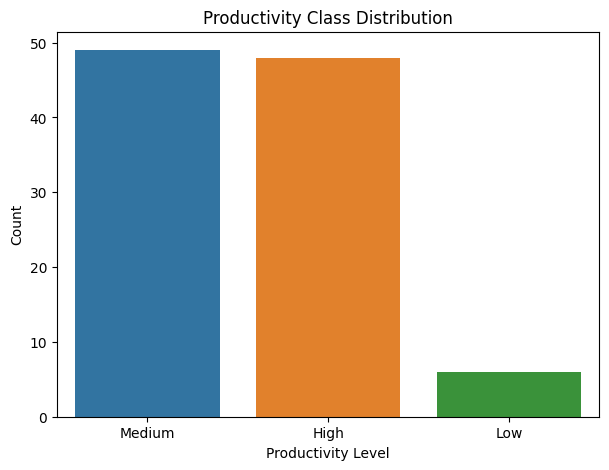

In [14]:
# STEP 12 — EDA VISUALIZATION 1
# PRODUCTIVITY DISTRIBUTION
plt.figure(figsize=(7,5))
sns.countplot(x='productivity', data=df)
plt.title("Productivity Class Distribution")
plt.xlabel("Productivity Level")
plt.ylabel("Count")
plt.show()

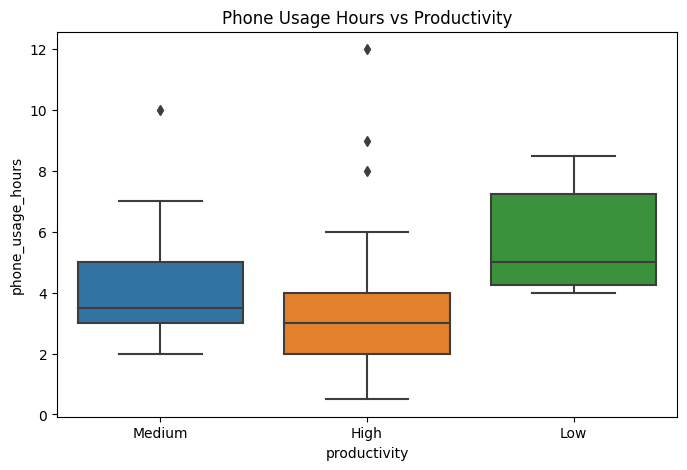

In [15]:
# STEP 13 — EDA VISUALIZATION 2
# PHONE USAGE VS PRODUCTIVITY

plt.figure(figsize=(8,5))

sns.boxplot(
    x='productivity',
    y='phone_usage_hours',
    data=df
)

plt.title("Phone Usage Hours vs Productivity")

plt.show()

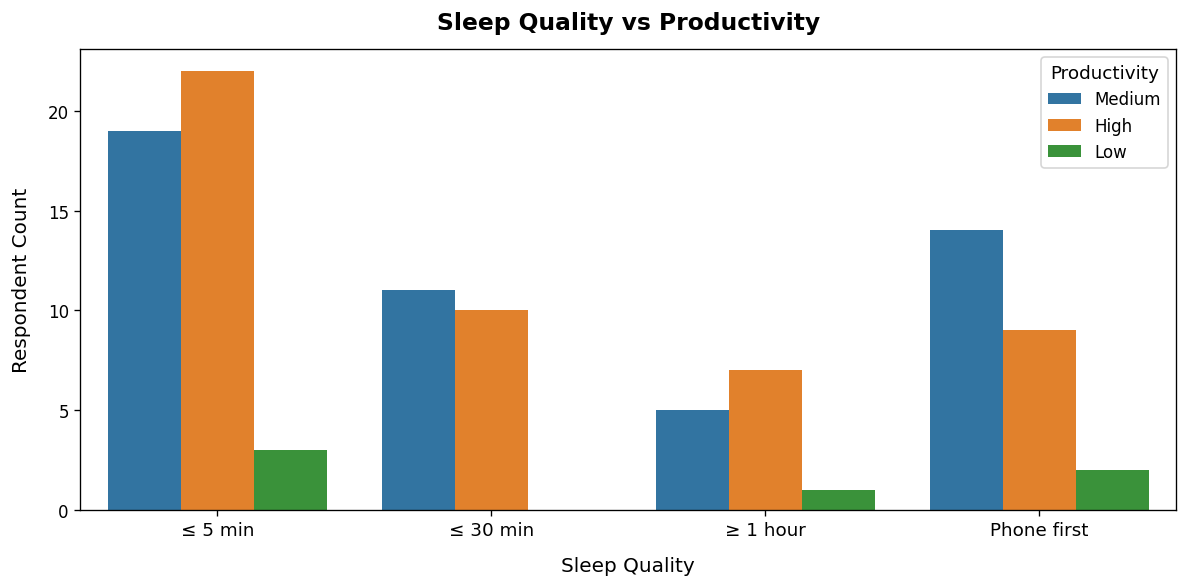

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make text sharper
plt.rcParams["figure.dpi"] = 120

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    x='sleep_quality',
    hue='productivity',
    data=df
)

# Crisp title and labels
ax.set_title("Sleep Quality vs Productivity", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Sleep Quality", fontsize=12, labelpad=10)
ax.set_ylabel("Respondent Count", fontsize=12, labelpad=10)

# Make x labels cleaner (shortened + wrapped)
ax.set_xticklabels([
    "≤ 5 min",
    "≤ 30 min",
    "≥ 1 hour",
    "Phone first"
], rotation=0, fontsize=11)

ax.legend(title="Productivity", title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()

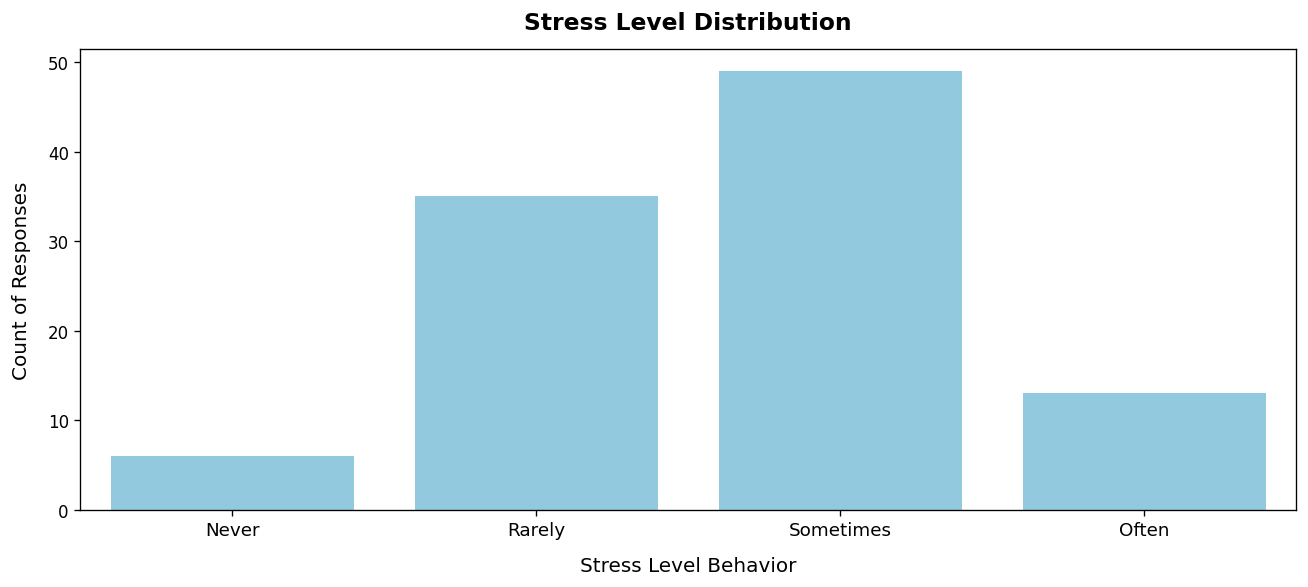

In [19]:
# STEP 15 — EDA VISUALIZATION 4
# STRESS LEVEL DISTRIBUTION

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 5), dpi=120)

order = [
    "Never — I keep it completely away while working",
    "Rarely — only during planned breaks",
    "Sometimes — I check it roughly every hour",
    "Often — I check it every few minutes"
]

ax = sns.countplot(
    x='stress_level',
    data=df,
    order=order,
    color='skyblue'
)

ax.set_title("Stress Level Distribution", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Stress Level Behavior", fontsize=12, labelpad=10)
ax.set_ylabel("Count of Responses", fontsize=12, labelpad=10)

# Crisp, readable labels (shortened)
ax.set_xticklabels([
    "Never",
    "Rarely",
    "Sometimes",
    "Often"
], fontsize=11)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

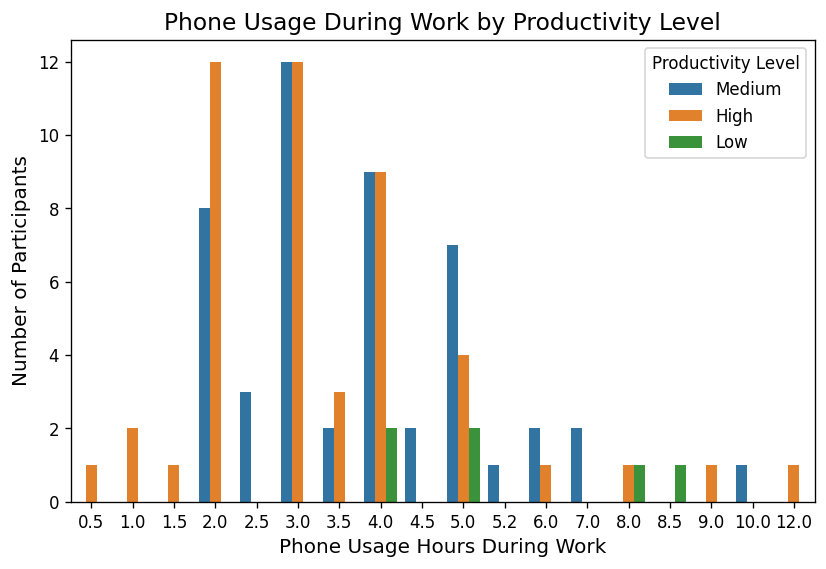

In [20]:
# STEP 16 — EDA VISUALIZATION 5
# PHONE USAGE HOURS DURING WORK VS PRODUCTIVITY

plt.figure(figsize=(8,5))

sns.countplot(
    x='phone_usage_hours',
    hue='productivity',
    data=df
)

plt.title("Phone Usage During Work by Productivity Level", fontsize=14)
plt.xlabel("Phone Usage Hours During Work", fontsize=12)
plt.ylabel("Number of Participants", fontsize=12)

plt.legend(title='Productivity Level')

plt.show()

In [19]:
# STEP 17 — ENCODE ORDINAL FEATURES

# Label mappings
consistency_map = {
    'Very consistent':3,
    'Mostly consistent':2,
    'Inconsistent':1
}

focus_map = {
    'High':3,
    'Medium':2,
    'Low':1
}

# apply only if values match
if 'sleep_consistency' in df.columns:
    df['sleep_consistency'] = df['sleep_consistency'].replace(consistency_map)

if 'focus_without_phone' in df.columns:
    df['focus_without_phone'] = df['focus_without_phone'].replace(focus_map)

In [20]:
# STEP 18 — LABEL ENCODING

label_encoders = {}

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    label_encoders[col] = le

df.head()

,age,gender,occupation,phone_usage_hours,sleep_hours,sleep_quality,sleep_consistency,phone_before_sleep,check_phone_after_wakeup,focus_without_phone,phone_interruptions,stress_level,work_study_hours,productivity
0,1,1,2,2.0,30.0,3,7.0,2.0,1,23,1,3,5.0,2
1,1,2,2,3.0,30.0,3,2.0,3.0,1,11,2,3,3.0,2
2,0,3,2,2.0,30.0,3,6.0,4.0,1,25,2,3,4.0,0
3,1,3,0,1.0,30.0,0,6.0,4.0,2,0,0,2,2.0,0
4,1,2,2,4.0,30.0,1,7.0,3.0,0,5,0,2,3.0,2


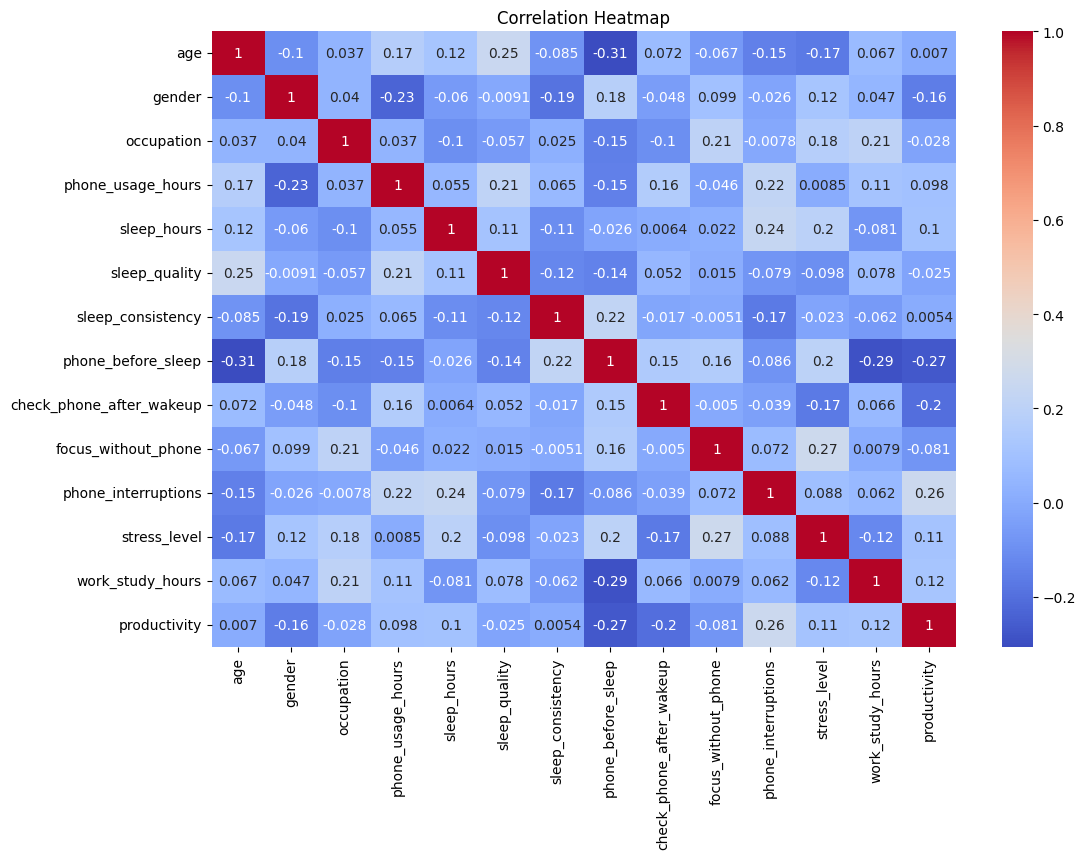

In [21]:
# STEP 19 — CORRELATION HEATMAP

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103 entries, 0 to 102
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       103 non-null    int32  
 1   gender                    103 non-null    int32  
 2   occupation                103 non-null    int32  
 3   phone_usage_hours         103 non-null    float64
 4   sleep_hours               103 non-null    float64
 5   sleep_quality             103 non-null    int32  
 6   sleep_consistency         103 non-null    float64
 7   phone_before_sleep        103 non-null    float64
 8   check_phone_after_wakeup  103 non-null    int32  
 9   focus_without_phone       103 non-null    int32  
 10  phone_interruptions       103 non-null    int32  
 11  stress_level              103 non-null    int32  
 12  work_study_hours          103 non-null    float64
 13  productivity              103 non-null    int32  
dtypes: float64(5), 

In [23]:
# STEP 20 — DEFINE FEATURES AND TARGET
X = df[
    [
        'phone_usage_hours',
        'sleep_hours',
        'sleep_quality',
        'stress_level',
        'phone_interruptions',
        'focus_without_phone',
        'phone_before_sleep',
        'sleep_consistency'
    ]
]
y = df['productivity']
print(X.shape)
print(y.shape)

(103, 8)
(103,)


In [26]:
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(X_resampled.shape)
print(y_resampled.shape)

(147, 8)
(147,)


In [27]:
# STEP 21 — TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [28]:
# STEP 22 — FEATURE SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
# STEP 23 — DATA READY FOR MODELING

print("Preprocessing Completed Successfully")

print("\nTraining Data Shape:")
print(X_train_scaled.shape)

print("\nTesting Data Shape:")
print(X_test_scaled.shape)

Preprocessing Completed Successfully

Training Data Shape:
(117, 8)

Testing Data Shape:
(30, 8)


In [33]:
# =========================================================
# MODEL 1 — RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# create model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# train model
rf.fit(X_train, y_train)

# predictions
y_pred_rf = rf.predict(X_test)

# evaluation
print("RANDOM FOREST RESULTS")
print("="*40)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy:
0.7333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       1.00      1.00      1.00        10
           2       0.62      0.50      0.56        10

    accuracy                           0.73        30
   macro avg       0.74      0.73      0.73        30
weighted avg       0.74      0.73      0.73        30


Confusion Matrix:
[[ 7  0  3]
 [ 0 10  0]
 [ 5  0  5]]


In [34]:
# =========================================================
# MODEL  2 — DECISION TREE CLASSIFIER
# =========================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# create model
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

# train model
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# predictions
y_pred_dt = dt.predict(X_test)

# evaluation
print("DECISION TREE RESULTS")
print("="*40)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

DECISION TREE RESULTS
Accuracy:
0.7333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.80      0.67        10
           1       1.00      1.00      1.00        10
           2       0.67      0.40      0.50        10

    accuracy                           0.73        30
   macro avg       0.75      0.73      0.72        30
weighted avg       0.75      0.73      0.72        30


Confusion Matrix:
[[ 8  0  2]
 [ 0 10  0]
 [ 6  0  4]]


In [35]:
# =========================================================
# MODEL 3 — XGBOOST CLASSIFIER
# =========================================================

from xgboost import XGBClassifier

# create model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

# train model
xgb.fit(X_train, y_train)

# predictions
y_pred_xgb = xgb.predict(X_test)

# evaluation
print("XGBOOST RESULTS")
print("="*40)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBOOST RESULTS
Accuracy:
0.7666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       1.00      1.00      1.00        10
           2       0.64      0.70      0.67        10

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.77        30
weighted avg       0.77      0.77      0.77        30


Confusion Matrix:
[[ 6  0  4]
 [ 0 10  0]
 [ 3  0  7]]


In [36]:
# =========================================================
# MODEL — LOGISTIC REGRESSION
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# create model
lr = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# train model
lr.fit(X_train_scaled, y_train)

# predictions
y_pred_lr = lr.predict(X_test_scaled)

# evaluation
print("LOGISTIC REGRESSION RESULTS")
print("="*40)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:
0.7666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        10
           1       0.83      1.00      0.91        10
           2       0.86      0.60      0.71        10

    accuracy                           0.77        30
   macro avg       0.78      0.77      0.76        30
weighted avg       0.78      0.77      0.76        30


Confusion Matrix:
[[ 7  2  1]
 [ 0 10  0]
 [ 4  0  6]]
